# Random forests

## Why ensembles?

A single [decision tree](decision-trees.ipynb) tends to overfit: it has high *variance*, meaning small changes in the training data can produce a very different tree. *Ensemble methods* combine many trees to produce predictions that are more accurate and more stable than any individual tree. Random forests are the classic *bagging* strategy; the other major strategy is *boosting* ([gradient boosting](gradient-boost.ipynb)).

## Random forests (bagging)

A random forest builds $M$ decision trees independently and in parallel, each on a *bootstrap* sample (random sample with replacement) of the training data, and additionally restricts each split to a random subset of features. Predictions are then averaged (regression) or majority-voted (classification) across all trees,

$$
\hat{y} = \frac{1}{M} \sum_{m=1}^{M} T_m(\boldsymbol{x})
$$

where $T_m$ denotes the prediction of the $m$-th tree. Averaging many noisy, independently trained, mostly-uncorrelated trees reduces the overall variance without increasing bias — individual trees can be deep and somewhat overfit, since their errors tend to cancel out in the average. This is why random forests reduce *variance* rather than *bias*: unlike boosting, adding more trees essentially never hurts.

## Library imports

In [1]:
import matplotlib.pyplot as plt
import sklearn


## Data preparation

We reuse the breast cancer data set from the [decision tree notebook](decision-trees.ipynb).

In [2]:
cancer = sklearn.datasets.load_breast_cancer()
X, y = cancer["data"], cancer["target"]

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=0,
)


## Model definition and training

We build a forest of 200 trees, Eq. (1), each trained on a bootstrap sample with a random subset of features considered at every split.

In [3]:
rf = sklearn.ensemble.RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=0,
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(sklearn.metrics.classification_report(y_test, y_pred_rf, target_names=cancer["target_names"]))


              precision    recall  f1-score   support

   malignant       0.91      0.95      0.93        42
      benign       0.97      0.94      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



## Effect of ensemble size: out-of-bag error

Because each tree only sees a bootstrap sample (roughly 63% of the training set), the remaining *out-of-bag* (OOB) samples can be used as a free internal validation set, without touching the held-out test set. We track the OOB accuracy as trees are added, illustrating that bagging error decreases and then plateaus — it does not go back up as $M$ grows, which is the practical signature of variance reduction.

In [4]:
# Suppress warning due to inaccurate OOB estimation,
# due to low amounts of trees
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

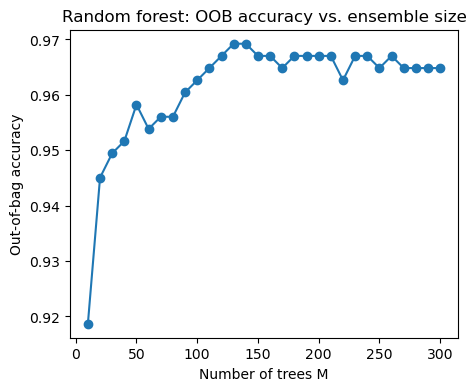

In [5]:
n_estimators_range = range(10, 301, 10)
oob_scores = []

for n in n_estimators_range:
    rf_oob = sklearn.ensemble.RandomForestClassifier(
        n_estimators=n, max_depth=None, oob_score=True, random_state=0,
    )
    rf_oob.fit(X_train, y_train)
    oob_scores.append(rf_oob.oob_score_)

plt.figure(figsize=(5, 4))
plt.plot(list(n_estimators_range), oob_scores, "o-")
plt.xlabel("Number of trees M")
plt.ylabel("Out-of-bag accuracy")
plt.title("Random forest: OOB accuracy vs. ensemble size")
plt.show()


## Comparing a single tree to the random forest

To highlight the effect of bagging, we also fit a single decision tree of comparable depth and compare test accuracy.

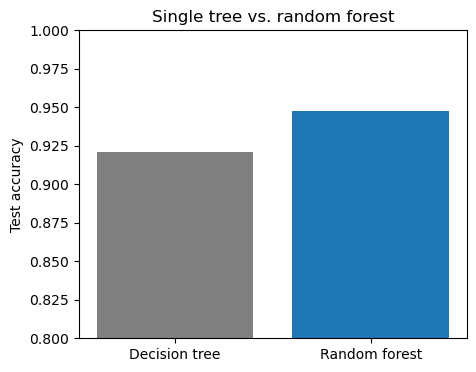

In [6]:
tree = sklearn.tree.DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)

models = {
    "Decision tree": tree,
    "Random forest": rf,
}
accuracies = {name: sklearn.metrics.accuracy_score(y_test, m.predict(X_test)) for name, m in models.items()}

plt.figure(figsize=(5, 4))
plt.bar(accuracies.keys(), accuracies.values(), color=["gray", "tab:blue"])
plt.ylabel("Test accuracy")
plt.ylim(0.8, 1.0)
plt.title("Single tree vs. random forest")
plt.show()


## Model evaluation

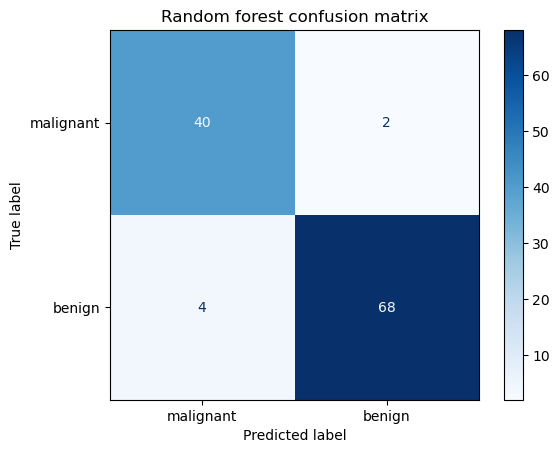

In [7]:
cm = sklearn.metrics.confusion_matrix(y_test, y_pred_rf)
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer["target_names"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Random forest confusion matrix")
plt.show()


## Feature importance

As with a single tree, the forest provides an aggregated feature importance, averaged over all 200 trees.

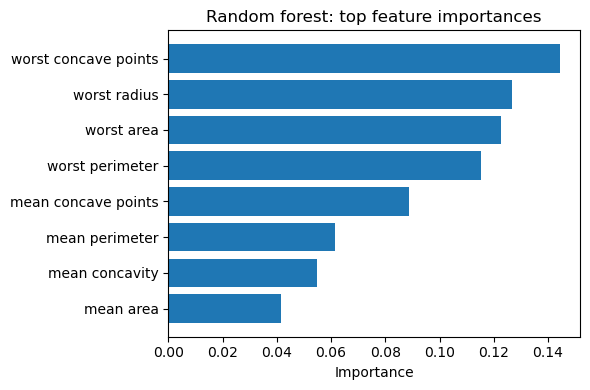

In [8]:
importances = rf.feature_importances_
order = importances.argsort()[::-1][:8]

plt.figure(figsize=(6, 4))
plt.barh(
    [cancer["feature_names"][i] for i in order][::-1],
    importances[order][::-1],
)
plt.xlabel("Importance")
plt.title("Random forest: top feature importances")
plt.tight_layout()
plt.show()


## Take-away

Random forests are an excellent default choice for tabular data with limited resources: they require little preprocessing (no feature scaling), handle a mix of numerical and categorical features well, and are robust to hyperparameter choices — they rarely need extensive tuning, and adding more trees essentially never hurts. Their main weakness relative to boosting (companion notebook) is that they typically leave a bit of predictive performance on the table, since averaging independent trees reduces variance but does nothing to reduce bias.